# Uber Rides Data Analysis Using Python

## Importing Required Libraries

The required Python libraries are imported to perform data manipulation, numerical operations, and data visualization.

- **Pandas** is used for data manipulation and analysis.
- **NumPy** is used for numerical and mathematical operations.
- **Matplotlib** is used to create graphs and visualizations.
- **Seaborn** is used to create attractive and informative statistical visualizations.

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the Dataset

The Uber rides dataset is loaded from the CSV file using the `read_csv()` function of the Pandas library. The `head()` function is then used to display the first five records of the dataset.

Displaying the initial records helps to understand the structure of the dataset, identify the available columns, and get an overview of the type of information contained in the data.

In [52]:
dataset = pd.read_csv("/kaggle/input/datasets/nemisruparel/uberdataset/UberDataset.csv")
dataset.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


## Checking the Dataset Dimensions

The `shape` attribute is used to determine the dimensions of the dataset. It returns the number of **rows** and **columns** present in the dataset.

This helps us understand the overall size of the dataset before performing further analysis.

In [53]:
dataset.shape

(1156, 7)

## Understanding the Dataset Information

The `info()` method is used to obtain a concise summary of the dataset. It provides information about the number of entries, column names, number of non-null values, and data types of each column.

This helps understand the initial structure of the dataset, identify missing values, and determine the appropriate data types before performing data cleaning and further analysis.

In [54]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   START_DATE  1156 non-null   object 
 1   END_DATE    1155 non-null   object 
 2   CATEGORY    1155 non-null   object 
 3   START       1155 non-null   object 
 4   STOP        1155 non-null   object 
 5   MILES       1156 non-null   float64
 6   PURPOSE     653 non-null    object 
dtypes: float64(1), object(6)
memory usage: 63.3+ KB


# Dataset Preprocessing

Data preprocessing is performed to prepare the dataset for further analysis. It involves identifying and handling missing values, correcting data inconsistencies, and transforming the data into a suitable format for analysis.

### Handling Missing Values in the `PURPOSE` Column

The `PURPOSE` column contains missing values. These missing values are replaced with `"NOT"` using the `fillna()` method.

Using `"NOT"` allows the missing entries to be represented explicitly instead of leaving them as null values.

In [55]:
dataset['PURPOSE'] = dataset['PURPOSE'].fillna("NOT")

### Converting Date and Time Columns

The `START_DATE` and `END_DATE` columns contain date and time information. These columns are converted from their existing format into Pandas datetime format using the `pd.to_datetime()` function.

The `errors='coerce'` parameter converts any invalid or incorrectly formatted date values into `NaT` (Not a Time) instead of producing an error.

Converting these columns to datetime format makes it easier to perform further analysis based on dates and times, such as extracting the month, day, hour, or duration of each ride.

In [56]:
dataset['START_DATE'] = pd.to_datetime(dataset['START_DATE'], 
                                       errors='coerce')
dataset['END_DATE'] = pd.to_datetime(dataset['END_DATE'], 
                                     errors='coerce')

### Extracting Date and Time Features

The `START_DATE` column is used to extract additional features such as the date and hour of each ride.

The extracted hour is then grouped into four time-of-day categories:

- **Morning:** 0–10
- **Afternoon:** 11–15
- **Evening:** 16–19
- **Night:** 20–24

The `pd.cut()` function is used to categorize the ride times into these groups.

In [57]:
dataset['date'] = pd.DatetimeIndex(dataset['START_DATE']).date
dataset['time'] = pd.DatetimeIndex(dataset['START_DATE']).hour

dataset['day-night'] = pd.cut(x=dataset['time'],
                              bins=[-1, 10, 15, 19, 24],
                              labels = ['Morning','Afternoon','Evening','Night'])

### Removing Missing Values

After preprocessing the dataset, any remaining missing values are removed using the `dropna()` method.

The `inplace=True` parameter applies the changes directly to the existing dataset without creating a new DataFrame.

Removing incomplete records ensures that the remaining data can be used reliably for further analysis and visualization.

In [58]:
dataset.dropna(inplace=True)

### Removing Duplicate Records

Duplicate records can affect the accuracy of the analysis by counting the same ride more than once. The `drop_duplicates()` method is used to identify and remove duplicate rows from the dataset.

The `inplace=True` parameter applies the changes directly to the existing dataset.

In [59]:
dataset.drop_duplicates(inplace=True)

## Exploratory Data Analysis

In this section, we will explore and compare the different columns in the dataset to better understand the characteristics and patterns present in the Uber rides data.

### Checking Unique Values in Categorical Columns

First, we identify the columns having an `object` data type. These columns generally contain categorical or text-based data.

The number of unique values in each categorical column is then calculated. This helps us understand the variety of categories present in each column and provides an initial overview of the categorical features in the dataset.

In [60]:
obj = (dataset.dtypes == 'object')
object_cols = list(obj[obj].index)

unique_values = {}

for col in object_cols:
    unique_values[col] = dataset[col].unique().size

unique_values

{'CATEGORY': 2, 'START': 109, 'STOP': 113, 'PURPOSE': 7, 'date': 114}

### Distribution of Ride Category and Purpose

The `CATEGORY` and `PURPOSE` columns are visualized using count plots to understand the frequency of different types of Uber rides.

Two count plots are created side by side:

- The first plot represents the number of rides for each **CATEGORY**, such as Business and Personal.
- The second plot represents the number of rides for each **PURPOSE**, showing how frequently Uber was used for different activities.
- Different colors are used for the categories to make the visualization easier to distinguish and interpret.

The rotation of the x-axis labels improves readability, especially for the purpose categories.

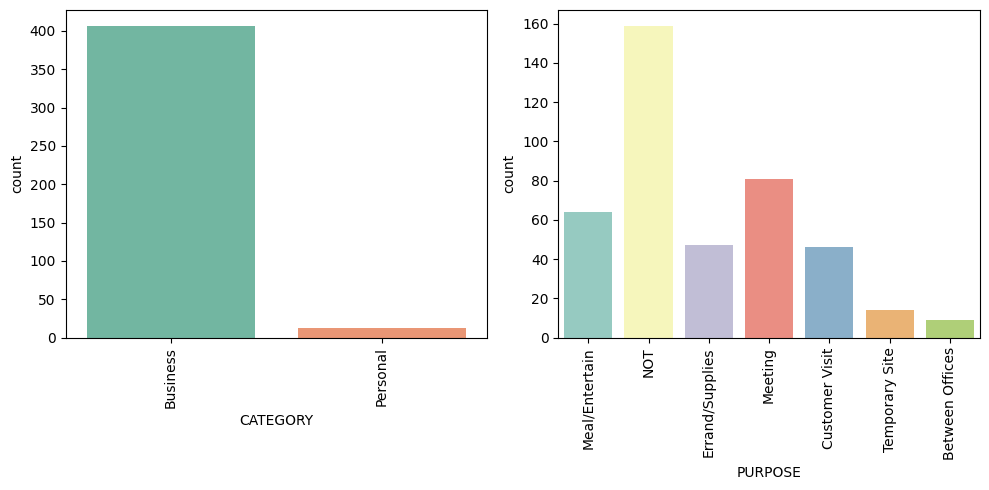

In [61]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.countplot(x=dataset['CATEGORY'],
              hue=dataset['CATEGORY'],
              palette='Set2',
              legend=False)
plt.xticks(rotation=90)

plt.subplot(1,2,2)
sns.countplot(x=dataset['PURPOSE'],
              hue=dataset['PURPOSE'],
              palette='Set3',
              legend=False)
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

### Distribution of Rides by Time of Day

The `day-night` column created during the preprocessing stage is used to analyze the distribution of Uber rides across different times of the day.

A count plot is used to display the number of rides in each time category:

- **Morning**
- **Afternoon**
- **Evening**
- **Night**

This visualization helps identify the times of day when Uber rides are more frequently recorded.

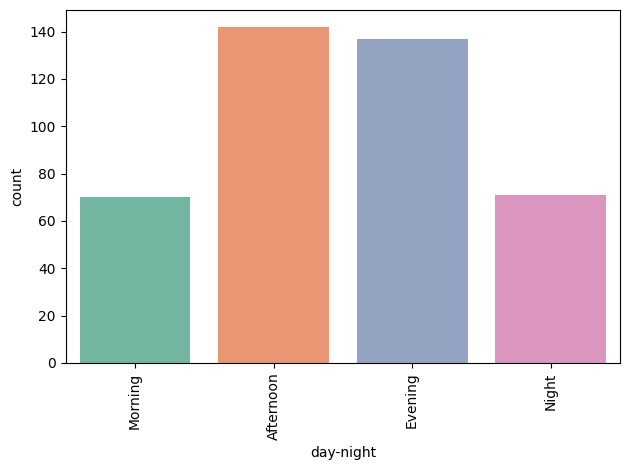

In [62]:
sns.countplot(x=dataset['day-night'],
              hue=dataset['day-night'],
              palette='Set2',
              legend=False)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Ride Purpose by Category

The relationship between `PURPOSE` and `CATEGORY` is analyzed using a grouped count plot.

The `PURPOSE` column is placed on the x-axis, while the `CATEGORY` column is used to distinguish between different ride categories. This allows us to compare the number of **Business** and **Personal** rides for each purpose.

The visualization helps identify which purposes are more commonly associated with business or personal Uber trips.

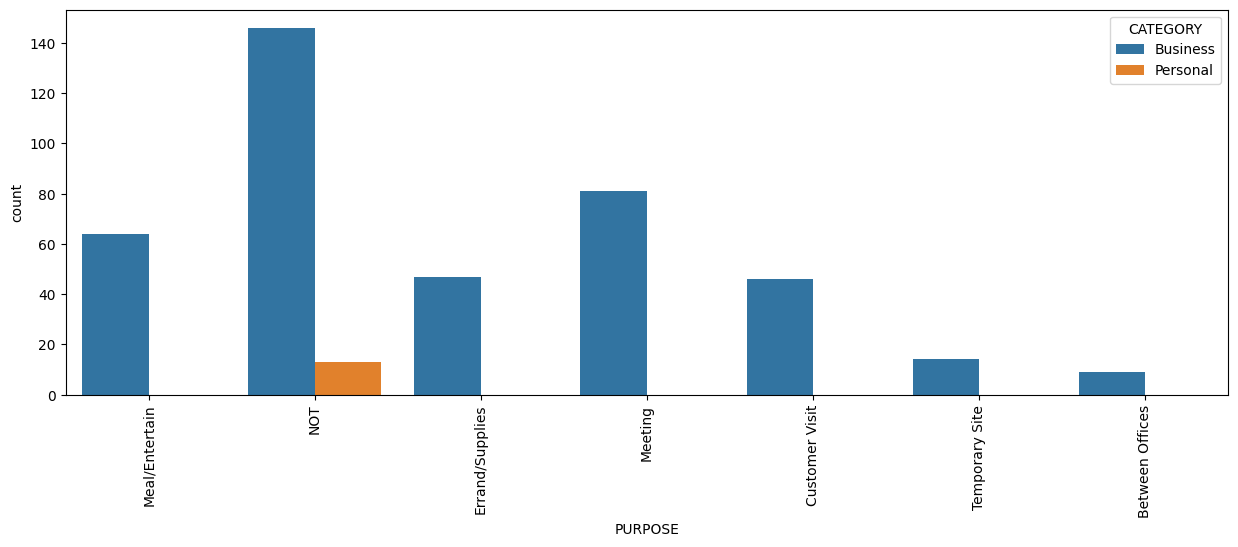

In [63]:
plt.figure(figsize=(15, 5))
sns.countplot(data=dataset, x='PURPOSE', hue='CATEGORY')
plt.xticks(rotation=90)
plt.show()

### Monthly Uber Ride Analysis

The month is extracted from the `START_DATE` column to analyze Uber ride activity across different months.

The numeric month values are converted into month names for better readability. The number of rides in each month is then calculated and visualized using a line plot.

This helps identify variations in Uber ride activity across different months.

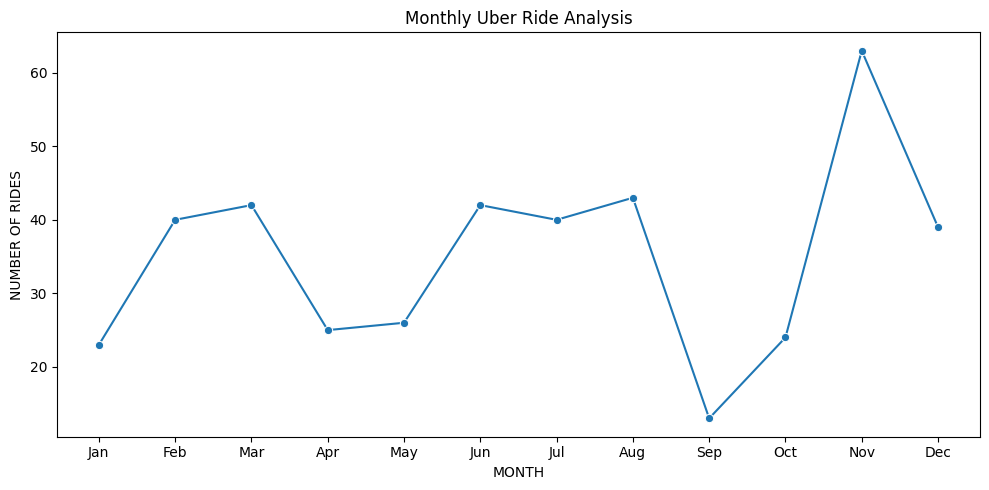

In [64]:
dataset['MONTH'] = dataset['START_DATE'].dt.month

month_label = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr',
    5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug',
    9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
}

dataset['MONTH'] = dataset['MONTH'].map(month_label)

monthly_rides = dataset['MONTH'].value_counts(sort=False)

plt.figure(figsize=(10, 5))
sns.lineplot(
    x=monthly_rides.index,
    y=monthly_rides.values,
    marker='o'
)

plt.xlabel('MONTH')
plt.ylabel('NUMBER OF RIDES')
plt.title('Monthly Uber Ride Analysis')
plt.tight_layout()
plt.show()

### Analyzing Uber Rides by Day of the Week

The `START_DATE` column is used to determine the day of the week on which each Uber ride started.

The `weekday` attribute returns a numerical value from **0 to 6**, where:

- **0** represents Monday
- **1** represents Tuesday
- **2** represents Wednesday
- **3** represents Thursday
- **4** represents Friday
- **5** represents Saturday
- **6** represents Sunday

These numerical values are converted into readable day names using a dictionary mapping.

The `value_counts()` function is then used to calculate the total number of Uber rides recorded for each day of the week.

Finally, a bar plot is created to visualize the number of rides for each day. This helps identify which days have higher or lower Uber ride activity.

Text(0, 0.5, 'COUNT')

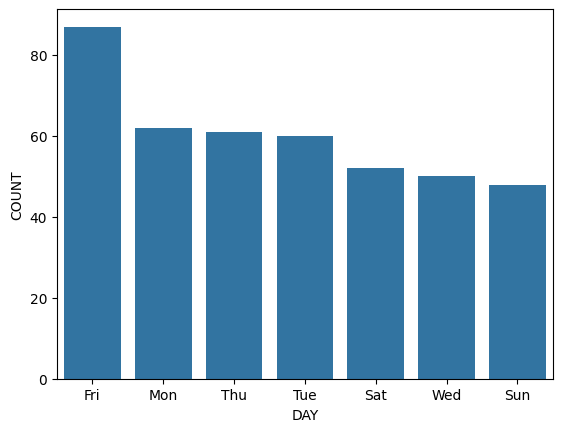

In [65]:
dataset['DAY'] = dataset.START_DATE.dt.weekday
day_label = {
    0: 'Mon',
    1: 'Tue',
    2: 'Wed',
    3: 'Thu',
    4: 'Fri',
    5: 'Sat',
    6: 'Sun'
}
dataset['DAY'] = dataset['DAY'].map(day_label)

day_label = dataset.DAY.value_counts()
sns.barplot(x=day_label.index, y=day_label);
plt.xlabel('DAY')
plt.ylabel('COUNT')

### Analyzing the Distribution of Miles

A box plot is used to visualize the distribution of the `MILES` column, which represents the distance traveled during Uber rides.

The box plot helps identify:

- The **median** distance traveled.
- The **lower and upper quartiles** of the ride distances.
- The overall spread of the data.
- Potential **outliers**, representing unusually short or long trips.

This visualization provides a clear understanding of the variation in Uber ride distances and helps identify extreme values in the dataset.

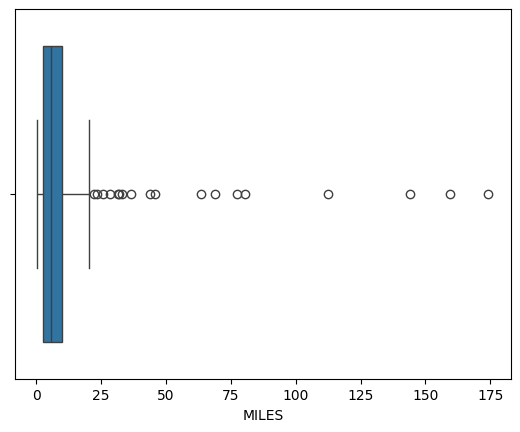

In [66]:
sns.boxplot(x=dataset['MILES'])
plt.xlabel('MILES')
plt.show()

### Box Plot for Rides Under 100 Miles

A box plot is created using only the Uber rides with a distance of less than **100 miles**.

Filtering the `MILES` column helps reduce the effect of extremely long trips and provides a clearer view of the distribution of typical Uber ride distances.

The box plot helps identify the **median, quartiles, spread, and potential outliers** among rides below 100 miles.

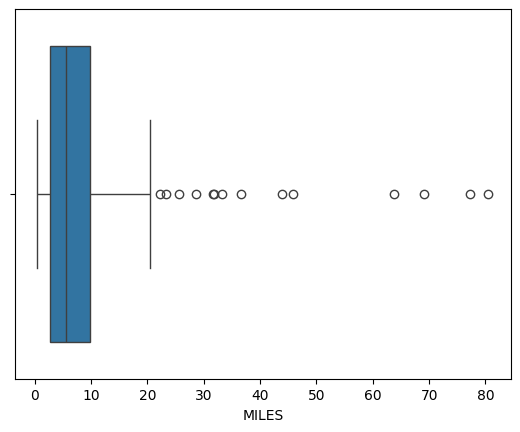

In [67]:
sns.boxplot(x=dataset[dataset['MILES'] < 100]['MILES'])
plt.xlabel('MILES')
plt.show()

### Distribution of Rides Under 40 Miles

A histogram is used to visualize the distribution of Uber ride distances for trips shorter than **40 miles**.

The `MILES` column is filtered to include only rides with distances below 40 miles. This makes it easier to observe the distribution of typical shorter trips without the influence of very long rides.

The `histplot()` function is used to display the frequency of different distance ranges. The `kde=True` parameter adds a **Kernel Density Estimate (KDE)** curve to show the overall shape of the distribution.

This visualization helps in understanding the most common ride distances and the overall distribution of shorter Uber trips.

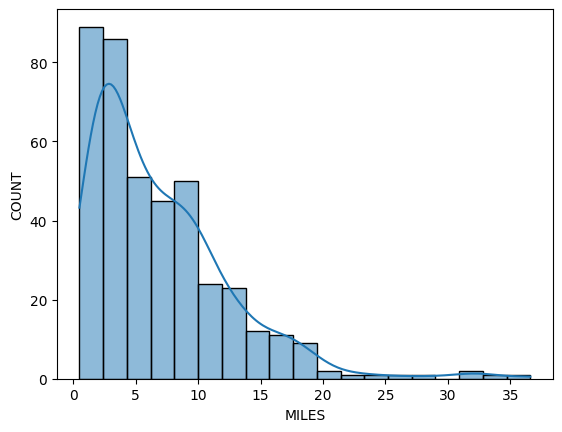

In [68]:
sns.histplot(dataset[dataset['MILES'] < 40]['MILES'], kde=True)
plt.xlabel('MILES')
plt.ylabel('COUNT')
plt.show()

# Feature Transformation

### Encoding Categorical Variables

The `CATEGORY` and `PURPOSE` columns contain categorical values, so they need to be converted into numerical form before performing further numerical analysis.

**One-Hot Encoding** is used with the `OneHotEncoder` class from Scikit-learn. Each unique category is converted into a separate binary column containing `0` or `1`.

The following steps are performed:

- The `CATEGORY` and `PURPOSE` columns are selected for encoding.
- `OneHotEncoder` converts the categorical values into numerical columns.
- `handle_unknown='ignore'` ensures that unknown categories do not cause errors.
- The original categorical columns are removed from the dataset.
- The newly generated encoded columns are combined with the remaining dataset.

This transformation makes the dataset suitable for numerical analysis and machine learning operations.

In [69]:
from sklearn.preprocessing import OneHotEncoder

object_cols = ['CATEGORY', 'PURPOSE']

OH_encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown='ignore'
)

OH_cols = pd.DataFrame(
    OH_encoder.fit_transform(dataset[object_cols])
)

OH_cols.index = dataset.index
OH_cols.columns = OH_encoder.get_feature_names_out()

df_final = dataset.drop(object_cols, axis=1)

dataset = pd.concat([df_final, OH_cols], axis=1)

# Correlation Analysis

### Correlation Heatmap

A correlation heatmap is created to examine the relationships between the numerical and one-hot encoded variables in the dataset.

Only numerical columns are selected using `select_dtypes()` because correlation calculations require numerical data.

The heatmap displays the correlation coefficient between pairs of numerical variables. The values range from **-1 to +1**:

- A value close to **+1** indicates a strong positive relationship.
- A value close to **-1** indicates a strong negative relationship.
- A value close to **0** indicates a weak or little linear relationship.

The `annot=True` parameter displays the correlation values directly on the heatmap, making the relationships easier to interpret.

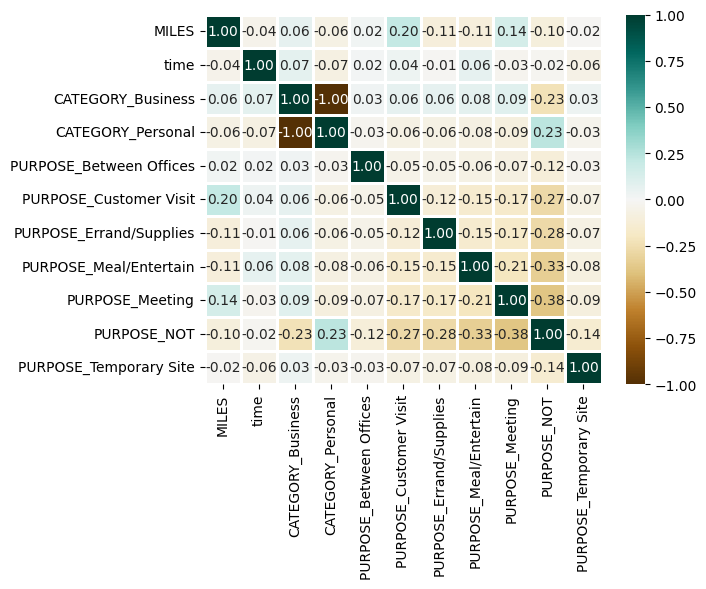

In [70]:
numeric_dataset = dataset.select_dtypes(include=['number'])

sns.heatmap(
    numeric_dataset.corr(),
    cmap='BrBG',
    fmt='.2f',
    linewidths=2,
    annot=True
)

plt.show()

## Conclusion

The Uber Rides Data Analysis project provides useful insights into Uber ride patterns by analyzing different attributes such as ride category, purpose, date, time, day of the week, and distance traveled.

During the analysis, the dataset was cleaned and preprocessed by handling missing values, removing duplicate records, converting date and time information, and creating additional features such as month, day, and time-of-day categories. Categorical variables were also converted into numerical form using One-Hot Encoding.

Various visualization techniques, including count plots, bar plots, line plots, box plots, histograms, and correlation heatmaps, were used to understand the data and identify patterns.

The analysis helps in understanding:

- The distribution of Uber rides across different categories and purposes.
- Ride frequency during different times of the day and days of the week.
- Monthly variations in Uber ride activity.
- The distribution and spread of ride distances.
- The presence of unusually long or short rides.
- Relationships between numerical and one-hot encoded variables.

Overall, this project demonstrates how **Python, Pandas, NumPy, Matplotlib, Seaborn, and Scikit-learn** can be used for data cleaning, exploratory data analysis, feature transformation, visualization, and extraction of meaningful insights from real-world ride data.